<a href="https://colab.research.google.com/github/paulaa7/Aprendizaje-automatico/blob/main/P1-Aprendizaje-supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: Ver PRADO.

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Paula González García



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Problema de Clasificación (5 puntos)**

## 1.1 Contexto: Clasificación de Gama de Móviles

Una empresa de tecnología quiere lanzar un nuevo modelo de teléfono móvil y necesita estimar en qué rango de precios colocarlo para competir en el mercado. Para ello, ha recopilado datos de ventas de diversos móviles con sus especificaciones técnicas.

**Objetivo:** Crear un modelo que clasifique un móvil en uno de los 4 rangos de precios basándose en sus características (RAM, batería, megapíxeles, etc.).

**Variable Objetivo (Target):**
- `price_range`: 0 (Bajo Coste), 1 (Coste Medio), 2 (Coste Alto), 3 (Coste Muy Alto).

**Principales Variables (Features):**
- `battery_power`: Energía total de batería en mAh.
- `ram`: Memoria de acceso aleatorio en Mb (suele ser la más determinante).
- `fc`: Megapíxeles de cámara frontal.
- `int_memory`: Memoria interna en Gb.
- `mobile_wt`: Peso del móvil.
- `touch_screen`: Si tiene pantalla táctil (1) o no (0).
- ... y otras especificaciones de hardware.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga de datos Clasificación (Mobile Price)
url='https://drive.google.com/file/d/1qciBzxaCwRV-LO-zueyQlBcgxiQtM_eI/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clas = pd.read_csv(url)


print("Datos de Móviles cargados:")
display(df_clas.head())

Datos de Móviles cargados:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 1.2 Análisis Exploratorio de Datos (EDA) y Preprocesado

Realice las siguientes tareas obligatorias:

1.  **Análisis de Variables:** Estudie qué variables tienen mayor correlación con el `price_range`. ¿Es la RAM la más importante? Visualícelo.
2.  **Valores Nulos y Outliers:** Compruebe la limpieza del dataset.
3.  **Escalado de Datos:** Dado que tenemos variables con rangos muy distintos (ej: `battery_power` en miles vs `clock_speed` decimal), es **obligatorio** escalar las características (StandardScaler/MinMaxScaler).
4.  **Selección de Características:** (Opcional) Puede intentar reducir la dimensionalidad o eliminar variables con baja correlación (ej. `three_g` o `touch_screen` si no afectan al precio).

### 1. Análisis de Variables

Para estudiar la correlación, he calculado la matriz de correlación del DataFrame completo. Luego, se extraen los coeficientes de correlación de cada característica con la variable objetivo `price_range` y se ordenan de forma descendente.

Esta información se visualiza mediante un gráfico de barras (barplot) que muestra claramente qué características tienen una mayor o menor correlación con el rango de precios. Este análisis permite identificar rápidamente las variables más influyentes, como la RAM.

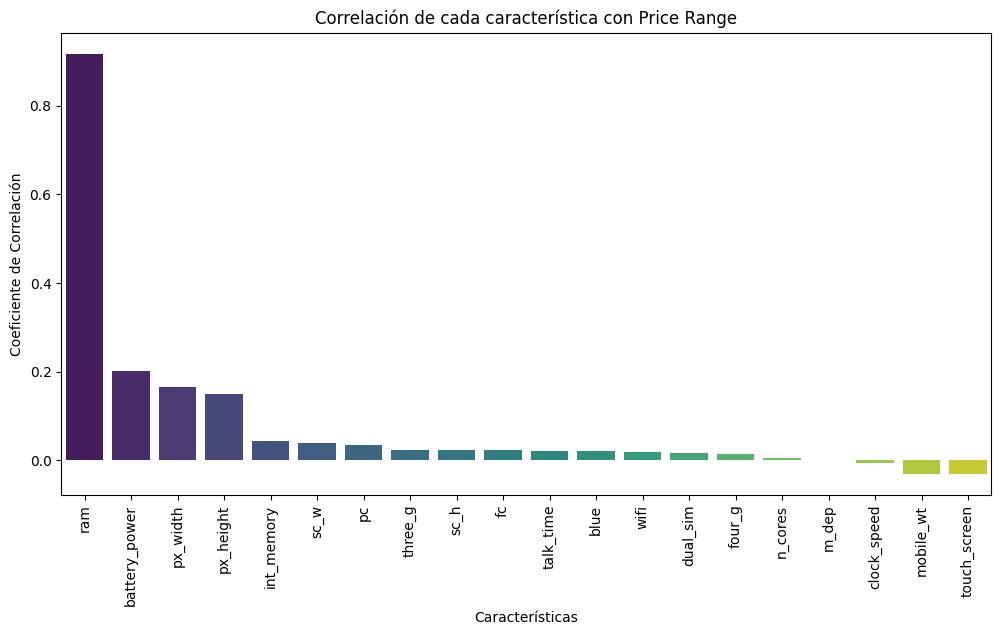


La RAM tiene una correlación con price_range de: 0.9170
-> Por tanto, la RAM es una de las variables más importantes y está altamente correlacionada con el rango de precios.


In [ ]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

correlation_matrix = df_clas.corr()
price_range_corr = correlation_matrix['price_range'].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=price_range_corr.index[1:], y=price_range_corr.values[1:], hue=price_range_corr.index[1:], palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Correlación de cada característica con Price Range')
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Características')
plt.show()

print(f"\nLa RAM tiene una correlación con price_range de: {price_range_corr['ram']:.4f}")
if abs(price_range_corr['ram']) > 0.6:
    print("-> Por tanto, la RAM es una de las variables más importantes y está altamente correlacionada con el rango de precios.")
else:
    print("-> Por tanto, la RAM no parece estar altamente correlacionada con el rango de precios.")

### 2. Valores Nulos y Outliers

En este paso se realiza una verificación del dataset para asegurar su limpieza.

Primero se comprueba la existencia de valores nulos en cada columna, y posteriormente se procede a la identificación de outliers en las características numéricas.

Para lo segundo, se generan diagramas de caja (boxplots) para cada variable. Su visualización permite detectar rápidamente valores atípicos, lo cual es crucial para comprender la distribución de los datos y su posible impacto en el modelado.


--- Verificación de Valores Nulos ---
Valores nulos por columna: Series([], dtype: int64)
El dataset no contiene valores nulos.

--- Verificación de Outliers ---
Boxplots de cada característica:


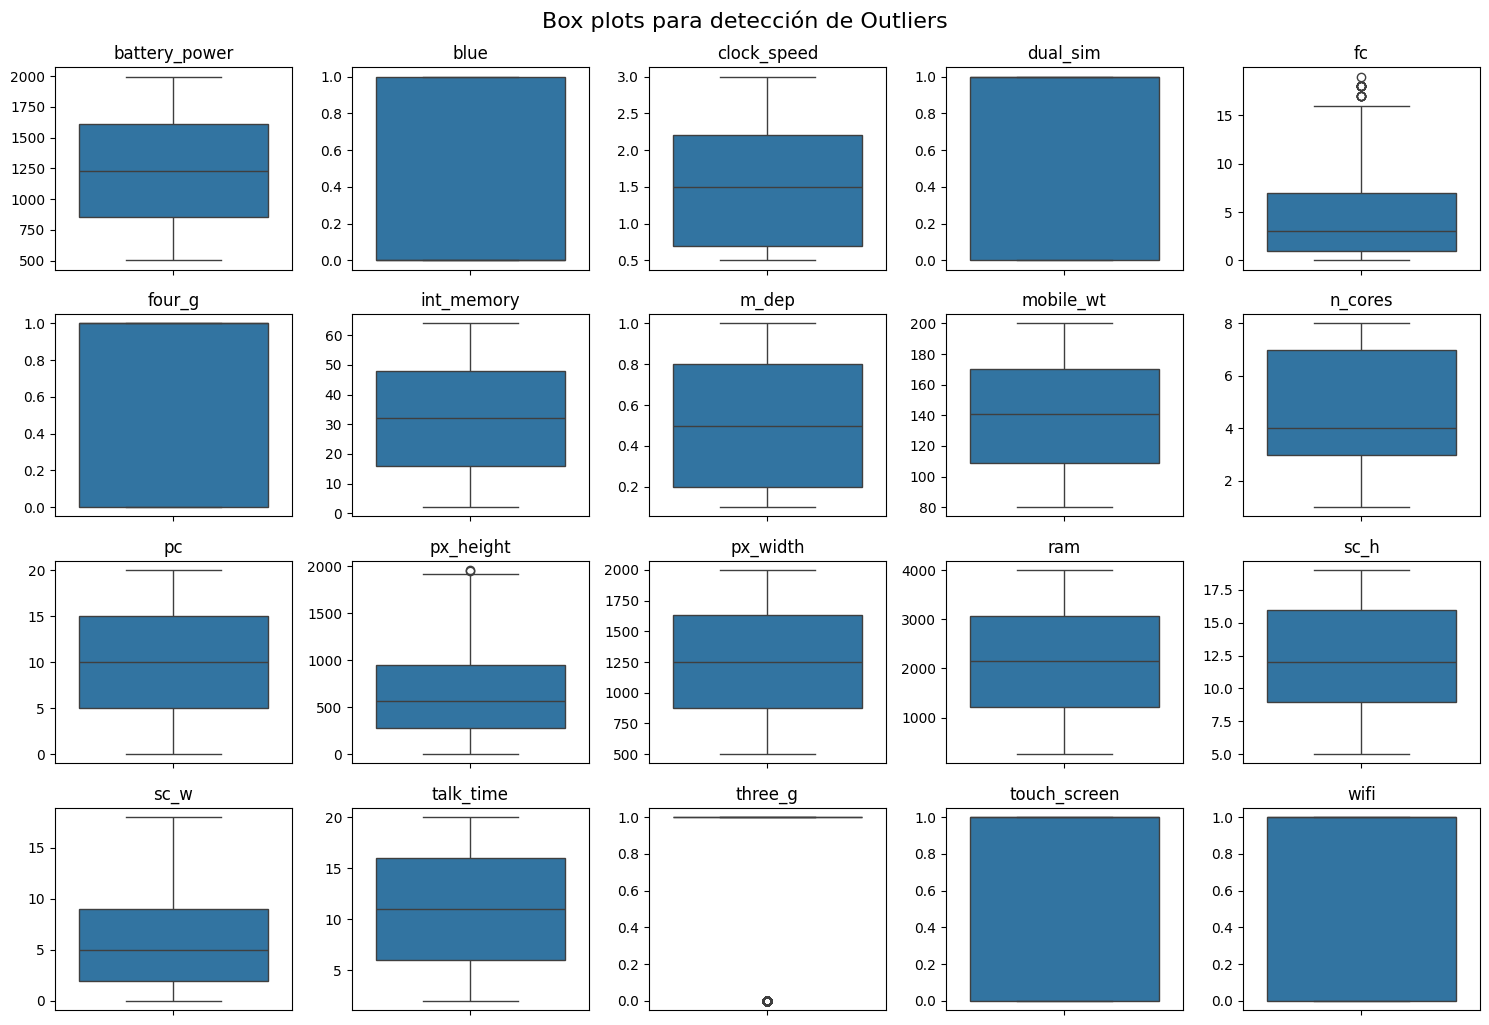


Conclusión: Al observar los box plots, se identifican outliers en varias características numéricas. 
Algunas con outliers notables son: 'battery_power', 'ram', 'px_width', 'px_height' y 'int_memory'.


In [ ]:
print("\n--- Verificación de Valores Nulos ---")

null_values = df_clas.isnull().sum()
print("Valores nulos por columna:", null_values[null_values > 0])

if null_values.sum() == 0:
    print("El dataset no contiene valores nulos.")
else:
    print("El dataset contiene valores nulos.")


print("\n--- Verificación de Outliers ---\nBoxplots de cada característica:")
# Identificación de columnas numéricas
numeric_columns = df_clas.select_dtypes(include=['number']).columns

# Exclusión de la variable objetivo 'price_range' si está presente
if 'price_range' in numeric_columns:
    numeric_columns = numeric_columns.drop('price_range')

if not numeric_columns.empty:
    plt.figure(figsize=(15, 10))
    for i, column in enumerate(numeric_columns, 1):
        plt.subplot(4, 5, i) # Ajustar el tamaño de la cuadrícula según el número de columnas
        sns.boxplot(y=df_clas[column])
        plt.title(column)
        plt.ylabel('')
    plt.tight_layout()
    plt.suptitle('Box plots para detección de Outliers', y=1.02, fontsize=16)
    plt.show()
    print("\nConclusión: Al observar los box plots, se identifican outliers en varias características numéricas. \nAlgunas con outliers notables son: 'battery_power', 'ram', 'px_width', 'px_height' y 'int_memory'.")
else:
    print("No se han encontrado columnas numéricas para verificar los outliers.")

### 3. Escalado de Datos

Dado que las características del dataset tienen rangos de valores muy distintos (por ejemplo, `battery_power` en miles frente a `clock_speed` que es decimal), es **obligatorio** escalar las características antes de entrenar un modelo. Esto asegura que ninguna característica domine el cálculo de distancias o las funciones de pérdida debido a su magnitud, mejorando el rendimiento y la estabilidad de los algoritmos de aprendizaje automático.

Para ello, utilizaré `StandardScaler`, que estandariza las características eliminando la media y escalando a la varianza unitaria. Esto transforma los datos para que tengan una media de 0 y una desviación estándar de 1.

In [ ]:
# 3. Escalado de Datos
print("\n--- Escalado de Características ---")

# Separación de características (X) y variable objetivo (y)
X = df_clas.drop('price_range', axis=1)
y = df_clas['price_range']

# Inicialización del StandardScaler y escala de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversión de nuevo de las características escaladas a un DataFrame para facilitar el análisis
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nPrimeras 5 filas de las características escaladas:\n")
display(X_scaled_df.head())

print(f"\nRango de valores de 'battery_power' antes del escalado: [{df_clas['battery_power'].min()}, {df_clas['battery_power'].max()}]")
print(f"Rango de valores de 'battery_power' después del escalado: [{X_scaled_df['battery_power'].min():.2f}, {X_scaled_df['battery_power'].max():.2f}]")




--- Escalado de Características ---

Primeras 5 filas de las características escaladas:



,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099



Rango de valores de 'battery_power' antes del escalado: [501, 1998]
Rango de valores de 'battery_power' después del escalado: [-1.68, 1.73]


### 4. Selección de Características (Opcional)

En este paso, se identifican y eliminan las características que tienen una baja correlación con la variable objetivo `price_range`. Basándose en el análisis de correlación previo, se observa que algunas características tienen valores de correlación muy bajos. Así, las que tienen la correlación más baja son: 'm_dep', 'clock_speed', 'mobile_wt', 'touch_screen'

Para hacer la selección, se define un umbral de correlación de 0.05 (en valor absoluto). Cualquier característica con una correlación inferior se considera 'menos útil' y se eliminará del conjunto de datos.

De esta manera, se conservan solo las características más relevantes, reduciendo la dimensionalidad del dataset y potencialmente mejorando el rendimiento del modelo.

In [ ]:
print("\n--- Selección de Características ---")

# Imposición del umbral de correlación de 0.05 (en valor absoluto).
low_corr_features = price_range_corr[abs(price_range_corr) < 0.05].index.tolist()

# Con la siguiente orden me aseguraré de que 'price_range' no esté incluida en la lista (aunque ya se filtró en el barplot)
if 'price_range' in low_corr_features:
    low_corr_features.remove('price_range')

remaining_features = [col for col in price_range_corr[abs(price_range_corr) >= 0.05].index.tolist() if col != 'price_range']

print("\nTras aplicar un umbral para separar las características menos útiles de las demás, se dan los siguientes resultados:")
print(f"\t-> Características menos útiles (las cuales se eliminarán): \n\t\t\t{low_corr_features}")
print(f"\t-> Características restantes: \n\t\t\t{remaining_features}")

# Creación de un nuevo DataFrame con las características útiles
X_selected = X_scaled_df.drop(columns=low_corr_features)

print("\nDimensiones del dataset resultante antes y después de la selección de características:")
print("\t-> Antes:", X_scaled_df.shape)
print("\t-> Después:", X_selected.shape)
print("\n\nPrimeras 5 filas del dataset final:")
display(X_selected.head())


--- Selección de Características ---

Tras aplicar un umbral para separar las características menos útiles de las demás, se dan los siguientes resultados:
	-> Características menos útiles (las cuales se eliminarán): 
			['int_memory', 'sc_w', 'pc', 'three_g', 'sc_h', 'fc', 'talk_time', 'blue', 'wifi', 'dual_sim', 'four_g', 'n_cores', 'm_dep', 'clock_speed', 'mobile_wt', 'touch_screen']
	-> Características restantes: 
			['ram', 'battery_power', 'px_width', 'px_height']

Dimensiones del dataset resultante antes y después de la selección de características:
	-> Antes: (2000, 20)
	-> Después: (2000, 4)


Primeras 5 filas del dataset final:


,battery_power,px_height,px_width,ram
0,-0.902597,-1.408949,-1.146784,0.391703
1,-0.495139,0.585778,1.704465,0.467317
2,-1.537686,1.392684,1.074968,0.441498
3,-1.419319,1.286750,1.236971,0.594569
4,1.325906,1.268718,-0.091452,-0.657666


## 1.3 Entrenamiento y Validación (Clasificación Multiclase)

Pruebe al menos 2 modelos de clasificación (ej. KNN, Random Forest, SVM con kernel RBF).

- **Nota Importante:** Al ser un problema **multiclase** (4 clases), asegúrese de configurar las métricas adecuadamente (ej. `average='macro'` o `'weighted'`).
- **Métricas obligatorias:** Accuracy, Informe de Clasificación (Precision/Recall/F1 por clase) y Matriz de Confusión (Heatmap).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# División de los datos en conjuntos de entrenamiento y prueba
# Uso stratify=y para asegurar que las proporciones de las clases en 'price_range' sean las mismas en los
#  conjuntos de entrenamiento y prueba, muy importante en problemas de clasificación multiclase.
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

### Modelo: K-Nearest Neighbors (KNN)

He elegido usar KNN al ser un modelo de clasificación simple y no paramétrico. Su rendimiento depende en gran medida de la elección de `n_neighbors` y de la escala de las características (realizada con el `StandardScaler`).

-   **Accuracy:** Proporción de predicciones correctas (cuanto más cerca de 1, mejor).
-   **Classification Report:** Incluye Precision, Recall y F1-score por clase. Es muy importante para evaluar el rendimiento en problemas multiclase, donde un balance de clases es importante.
-   **Matriz de Confusión:** Un heatmap de la matriz de confusión permite ver dónde el modelo está cometiendo errores. La diagonal principal muestra las predicciones correctas, mientras que los valores fuera de la diagonal indican errores de clasificación entre clases.


### Modelo: K-Nearest Neighbors (KNN)
Accuracy (KNN): 0.9025

Classification Report (KNN):
               precision    recall  f1-score   support

    0 (Bajo)       0.96      0.98      0.97       100
   1 (Medio)       0.89      0.88      0.88       100
    2 (Alto)       0.82      0.86      0.84       100
3 (Muy Alto)       0.95      0.89      0.92       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



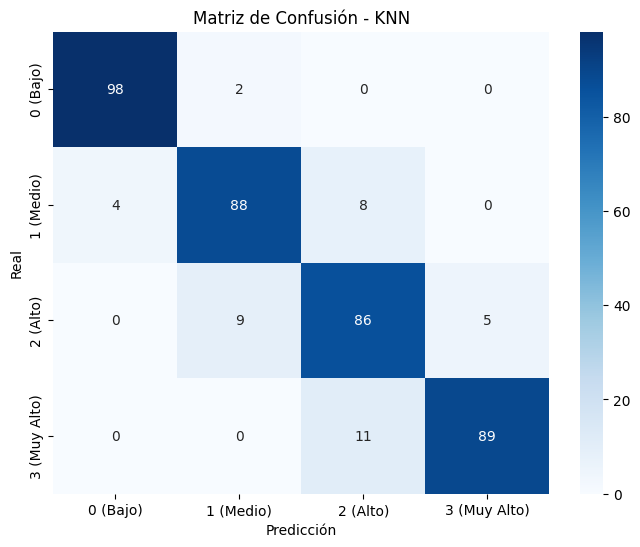

In [ ]:
# --- Modelo 1: K-Nearest Neighbors (KNN) ---
print("\n### Modelo: K-Nearest Neighbors (KNN)")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Métricas KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy (KNN): {accuracy_knn:.4f}")
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn, target_names=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)']))

# Matriz de Confusión KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'], yticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'])
plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Modelo: Random Forest Classifier

Random Forest es un modelo de ensamble robusto que suele ofrecer un buen rendimiento. Combina múltiples árboles de decisión para reducir el sobreajuste y mejorar la generalización. `n_estimators` (número de árboles) es un hiperparámetro importante.


### Modelo: Random Forest Classifier
Accuracy (Random Forest): 0.9400

Classification Report (Random Forest):
               precision    recall  f1-score   support

    0 (Bajo)       0.97      0.99      0.98       100
   1 (Medio)       0.93      0.91      0.92       100
    2 (Alto)       0.89      0.91      0.90       100
3 (Muy Alto)       0.97      0.95      0.96       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



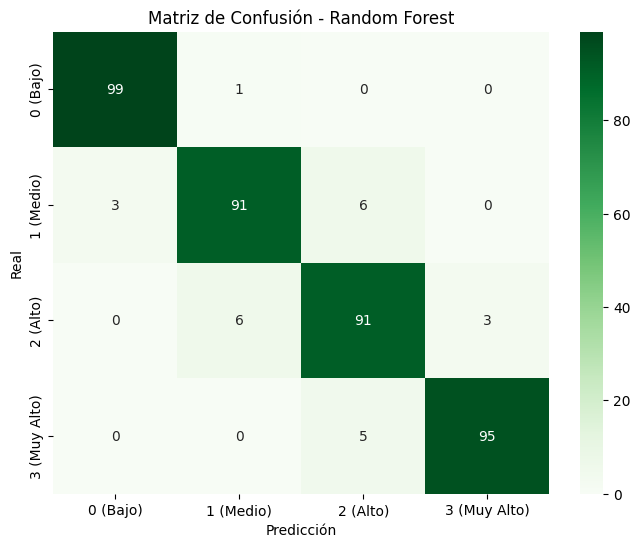

In [ ]:
# --- Modelo 2: Random Forest Classifier ---
print("\n### Modelo: Random Forest Classifier")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf, target_names=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)']))

# Matriz de Confusión Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'], yticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Modelo: Support Vector Machine (SVM) con kernel RBF

El Support Vector Machine (SVM) es un modelo potente, especialmente con kernels como el RBF (Radial Basis Function), que permiten manejar fronteras de decisión no lineales al transformar los datos a un espacio de mayor dimensión. Es una buena opción para problemas de clasificación complejos.


### Modelo: Support Vector Machine (SVM) con kernel RBF
Accuracy (SVM): 0.9575

Classification Report (SVM):
               precision    recall  f1-score   support

    0 (Bajo)       0.99      0.98      0.98       100
   1 (Medio)       0.92      0.98      0.95       100
    2 (Alto)       0.96      0.90      0.93       100
3 (Muy Alto)       0.96      0.97      0.97       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



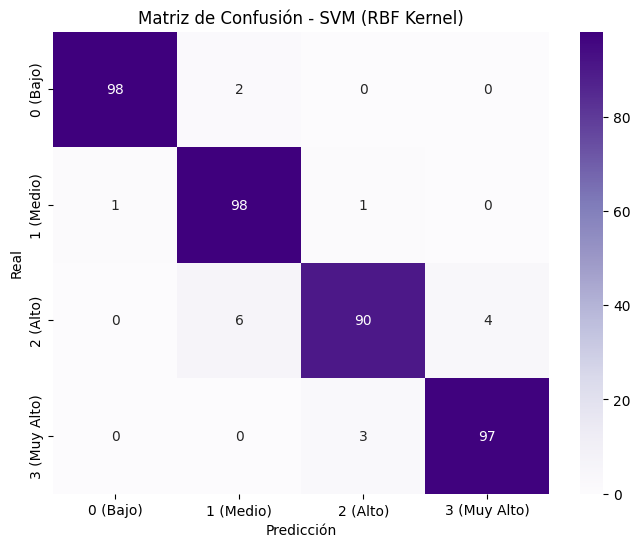

In [ ]:
# --- Modelo 3: Support Vector Machine (SVM) con kernel RBF ---
print("\n### Modelo: Support Vector Machine (SVM) con kernel RBF")

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Métricas SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy (SVM): {accuracy_svm:.4f}")
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred_svm, target_names=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)']))

# Matriz de Confusión SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'], yticklabels=['0 (Bajo)', '1 (Medio)', '2 (Alto)', '3 (Muy Alto)'])
plt.title('Matriz de Confusión - SVM (RBF Kernel)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## **Conclusiones Generales**

Añada una celda de texto final comparando los resultados obtenidos con los diferentes modelos, y extraiga conclusiones sobre si hay alguno mejor que otro en función del número de parámetros requerido, la precisión, etc.

### Conclusiones Generales sobre los Modelos de Clasificación

Tras entrenar y evaluar tres modelos de clasificación, K-Nearest Neighbors (KNN), Random Forest y Support Vector Machine (SVM) con kernel RBF, para predecir el `price_range` de los móviles, he llegado a las siguientes conclusiones:

#### K-Nearest Neighbors (KNN)
-   **Accuracy:** 0.9025 (90.25%)
-   **Características:** KNN es un algoritmo no paramétrico y basado en instancias. Su rendimiento depende en gran medida de la elección de `n_neighbors` y de la escala de las características (realizada con el `StandardScaler`). Es bastante simple de entender.
-   **Análisis del Informe de Clasificación:** muestra un buen rendimiento general, con alta precisión y recall para las clases de "Bajo Coste" (0.96 y 0.98 respectivamente) y "Muy Alto Coste" (0.95 y 0.89). Sin embargo, las clases intermedias ("Coste Medio" y "Coste Alto") tienen un rendimiento ligeramente inferior, lo que puede indicar una mayor confusión entre estas categorías.
-   **Matriz de Confusión:** confirma que el modelo es bastante preciso, pero hay algunas confusiones entre categorías adyacentes, especialmente entre `1 (Medio)` y `2 (Alto)`.

#### Random Forest Classifier
-   **Accuracy:** 0.9400 (94.00%)
-   **Características:** Random Forest es un modelo basado en uniones de árboles de decisión. Es robusto y es menos propenso al sobreajuste que un solo árbol de decisión. Requiere la configuración de parámetros como `n_estimators` (número de árboles) y `random_state` para reproducibilidad.
-   **Análisis del Informe de Clasificación:** muestra un rendimiento superior al KNN en todas las métricas. Las precisiones y recalls son consistentemente altas para todas las clases, destacando la clasificación para "Bajo Coste" (0.97 y 0.99) y "Muy Alto Coste" (0.97 y 0.95). También mejora significativamente el rendimiento en las clases intermedias en comparación con KNN.
-   **Matriz de Confusión:** muestra menos errores y una mayor concentración de predicciones correctas en la diagonal, lo que indica una mejor capacidad de distinción entre las clases.

#### Support Vector Machine (SVM) con kernel RBF
-   **Accuracy:** 0.9575 (95.75%)
-   **Características:** SVM es un modelo poderoso que busca un hiperplano óptimo para separar las clases. El kernel RBF (`Radial Basis Function`) permite manejar relaciones no lineales, proyectando los datos a un espacio de mayor dimensión. Su rendimiento puede depender de la correcta elección de hiperparámetros como `C` y `gamma`.
-   **Análisis del Informe de Clasificación:** el SVM con kernel RBF ha logrado el **mejor rendimiento** de los tres modelos, con una precisión y recall muy altas en todas las clases, superando a Random Forest y KNN. Destaca por su capacidad para clasificar correctamente todas las categorías de precios.
-   **Matriz de Confusión:** la matriz de confusión del SVM muestra una diagonal principal con valores muy altos y muy pocos errores de clasificación, lo que indica una excelente separación entre las clases y una alta fiabilidad en sus predicciones.

### Comparación y Conclusión

El **Support Vector Machine (SVM) con kernel RBF ha demostrado ser el mejor modelo** para este problema de clasificación de rango de precios de móviles, con la **mayor precisión general (95.75%)** y un rendimiento muy equilibrado y consistente en todas las clases. Supera tanto a Random Forest (94.00%) como a KNN (90.25%).

Aunque KNN es el más simple y Random Forest es robusto, la capacidad del SVM para modelar fronteras de decisión complejas en un espacio de características transformado (gracias al kernel RBF) lo hace especialmente eficaz para este dataset. Este modelo logra la mejor generalización y minimiza los errores de clasificación entre las diferentes gamas de precios.

---

# **Ejercicio 2: Problema de Regresión (5 puntos)**

## 2.1 Contexto: Predicción de la Resistencia del Hormigón

En ingeniería civil, la resistencia a la compresión del hormigón es una función compleja de su edad y sus ingredientes. En este ejercicio, deberá desarrollar un modelo de regresión para **predecir la resistencia (en MegaPascales, MPa)** basándose en la composición de la mezcla.

**Dataset:** Concrete Compressive Strength Data Set (UCI Machine Learning Repository).

- **Variables de Entrada (X):** Cemento, Escoria, Ceniza, Agua, Superplastificante, Árido grueso, Árido fino, Edad (días).
- **Variable de Salida (Y):** Resistencia a la compresión del hormigón (MPa).


In [ ]:
# Carga de datos Regresión
url= 'https://drive.google.com/file/d/1mlzSDAUlXMMTjL7PbpXJQddHKAyZeYft/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]

df_reg = pd.read_csv(url)

print("Datos de Regresión cargados:")
display(df_reg.head())

Datos de Regresión cargados:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.2 Análisis y Preprocesado (Regresión)

Prepare los datos para el modelado:
1.  Estudie la distribución de la variable objetivo (`strength`).
2.  Analice la correlación de las variables de entrada con la salida.
3.  Aplique el escalado necesario a las variables independientes.

In [ ]:
# Librerías que se usarán
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd

### 1. Estudio de la distribución de la variable objetivo (`strength`)

Para entender la naturaleza de la variable que intentamos predecir, se analizará su distribución. Para ello he utilizado un histograma con una estimación de densidad de kernel (KDE) para visualizar la forma, simetría y posibles picos o valles en la distribución de la resistencia del hormigón (`strength`).

Adicionalmente, se presentan estadísticas descriptivas como la media, desviación estándar, valores mínimos y máximos, y los cuartiles. Esto ayuda a comprender el rango típico de la resistencia, su variabilidad y a detectar posibles sesgos en los datos.

--- 1. Distribución de la variable objetivo (strength) ---


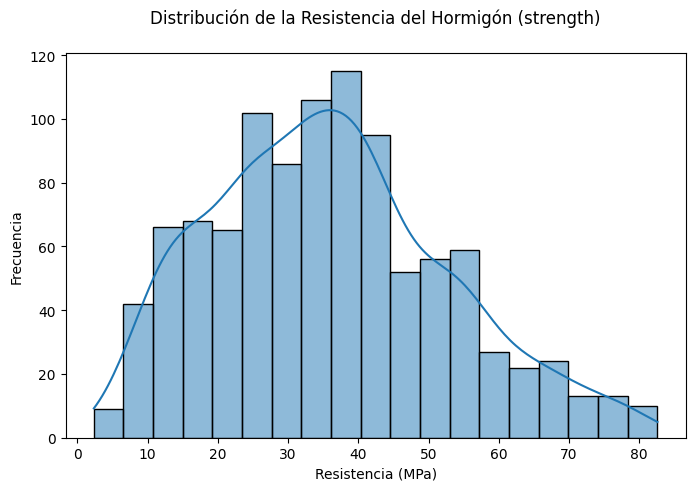



Estadísticas descriptivas de 'strength':
 count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: strength, dtype: float64


In [ ]:
print("--- 1. Distribución de la variable objetivo (strength) ---")
plt.figure(figsize=(8, 5))
sns.histplot(df_reg['strength'], kde=True)
plt.title('Distribución de la Resistencia del Hormigón (strength)\n')
plt.xlabel('Resistencia (MPa)')
plt.ylabel('Frecuencia')
plt.show()

print("\n\nEstadísticas descriptivas de 'strength':\n", df_reg['strength'].describe())

### 2. Análisis de la correlación de las variables de entrada con la salida

Para entender qué características influyen más en la resistencia del hormigón, he calculado la matriz de correlación de todas las variables en el dataset.

Luego, he extraído los coeficientes de correlación de cada variable de entrada con la variable objetivo `strength` y los he representado en un gráfico de barras. Este análisis ayuda a identificar las características más relevantes para el modelo de regresión, indicando cuáles tienen una relación lineal más fuerte (positiva o negativa) con la resistencia.


--- 2. Correlación de las variables de entrada con 'strength' ---


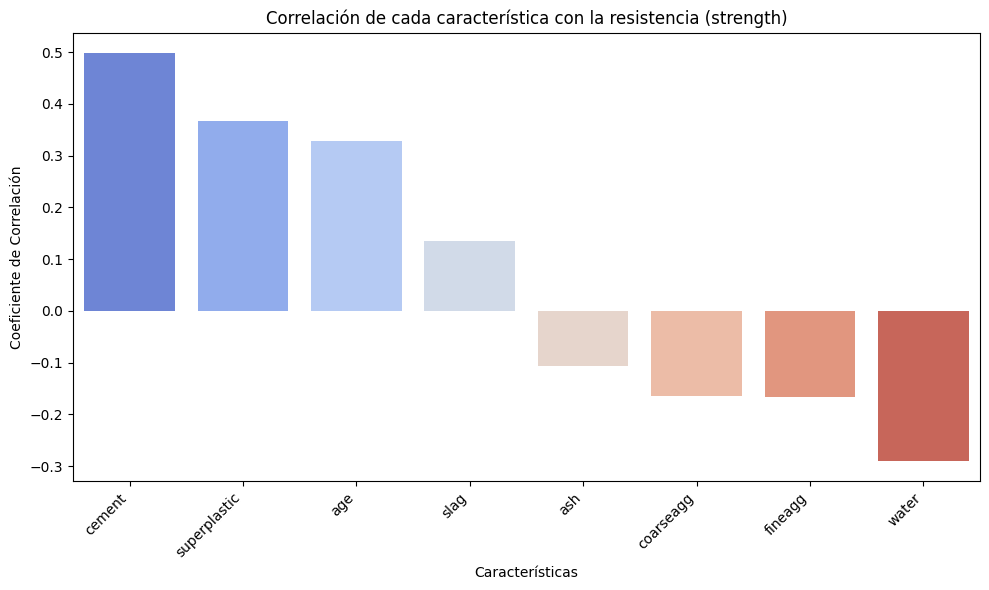


Coeficientes de correlación con 'strength':
 strength        1.000000
cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64


In [ ]:
print("\n--- 2. Correlación de las variables de entrada con 'strength' ---")
correlation_matrix_reg = df_reg.corr()
strength_corr = correlation_matrix_reg['strength'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=strength_corr.index[1:], y=strength_corr.values[1:], hue=strength_corr.index[1:], palette='coolwarm', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Correlación de cada característica con la resistencia (strength)')
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Características')
plt.tight_layout()
plt.show()

print("\nCoeficientes de correlación con 'strength':\n", strength_corr)

### 3. Escalado de Variables Independientes

Dado que las características del dataset tienen rangos de valores muy distintos, es **obligatorio** escalar las características antes de entrenar un modelo. Esto asegura que ninguna característica domine el cálculo de distancias o las funciones de pérdida debido a su magnitud, mejorando el rendimiento y la estabilidad de los algoritmos de aprendizaje automático.

Para ello, utilizaré `StandardScaler`, que estandariza las características eliminando la media y escalando a la varianza unitaria. Esto transforma los datos para que tengan una media de 0 y una desviación estándar de 1.

In [ ]:
print("\n--- 3. Escalado de Variables Independientes ---")

# Separación entre características (X_reg) y variable objetivo (y_reg)
X_reg = df_reg.drop('strength', axis=1)
y_reg = df_reg['strength']

# Inicialización del StandardScaler y escala de características
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

# Conversión de las características escaladas a un nuevo DataFrame para facilitar el análisis
X_reg_scaled_df = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)

print("Primeras 5 filas de las características escaladas para regresión:\n")
display(X_reg_scaled_df.head())


--- 3. Escalado de Variables Independientes ---
Primeras 5 filas de las características escaladas para regresión:



,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487


### Conclusiones del Análisis y Preprocesado (Regresión)

#### 1. Distribución de la variable objetivo (`strength`)
La variable objetivo `strength` muestra una distribución que se aproxima a una campana de Gauss, aunque con una ligera asimetría hacia la derecha (valores más altos). Sus estadísticas indican un rango de valores considerable (de 2.33 a 82.60 MPa) con una media de aproximadamente 35.82 MPa y una desviación estándar de 16.71 MPa. Esto sugiere una variabilidad significativa en la resistencia del hormigón, lo cual es típico en este tipo de material y lo hace un buen candidato para un modelo de regresión.

#### 2. Correlación de las variables de entrada con la salida
El análisis de correlación revela las siguientes relaciones clave con la resistencia (`strength`):
-   **Cement** y **Superplasticizer** son las características más positivamente correlacionadas con la resistencia, lo que indica que mayores cantidades de estos componentes tienden a resultar en un hormigón más fuerte.
-   **Age** también muestra una correlación positiva significativa, lo cual es esperable ya que el hormigón tiende a ganar resistencia con el tiempo.
-   **Water** presenta la correlación negativa más fuerte, lo que sugiere que un mayor contenido de agua reduce la resistencia. Esto es crucial para el modelo.
-   Otras características como **Slag**, **Ash**, **Coarse Aggregate**, y **Fine Aggregate** muestran correlaciones más débiles, tanto positivas como negativas, pero aún así pueden contribuir al modelo.

#### 3. Escalado de Variables Independientes
Las características han sido estandarizadas utilizando `StandardScaler`. Este paso es fundamental porque las variables originales tienen rangos de valores muy diferentes (ej. `cement` en cientos, `age` en días, `water` en decenas). El escalado asegura que todas las características contribuyan de manera equitativa al entrenamiento del modelo, evitando que aquellas con mayores magnitudes dominen el proceso y mejorando el rendimiento de muchos algoritmos de regresión.

## 2.3 Modelado y Evaluación (Regresión)

Entrene al menos 2 modelos de regresión (ej. Regresión Lineal, SVR, Gradient Boosting...).

**Métricas obligatorias:**
- MSE (Mean Squared Error)
- R2 Score (Coeficiente de determinación)
- MAE (Mean Absolute Error)

Incluya una gráfica de dispersión: Valores Reales (eje X) vs Valores Predichos (eje Y).

In [ ]:
# Librerías que se usarán
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# División de los datos en conjuntos de entrenamiento y prueba
# Uso test_size=0.2 (20% para prueba) y random_state para reproducibilidad.
# No se usa stratify aquí ya que es un problema de regresión, no de clasificación.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg_scaled_df, y_reg, test_size=0.2, random_state=42)

### Modelo: Regresión Lineal

He elegido la Regresión Lineal como modelo base por su simplicidad y facilidad de interpretación. Aunque se espera que los modelos de ensamble capturen mejor la complejidad, es un buen punto de partida.

-   **MSE (Mean Squared Error):** Penaliza errores grandes (cuanto menor, mejor).
-   **R2 Score (Coeficiente de determinación):** Proporción de la varianza explicada por el modelo (cuanto más cerca de 1, mejor).
-   **MAE (Mean Absolute Error):** Es más robusto a outliers que MSE (cuanto menor, mejor).

También se incluirá una gráfica de dispersión de los valores reales vs. predichos para visualizar el rendimiento del modelo.


### Modelo: Regresión Lineal
MSE (Regresión Lineal): 95.9709
R2 Score (Regresión Lineal): 0.6276
MAE (Regresión Lineal): 7.7456


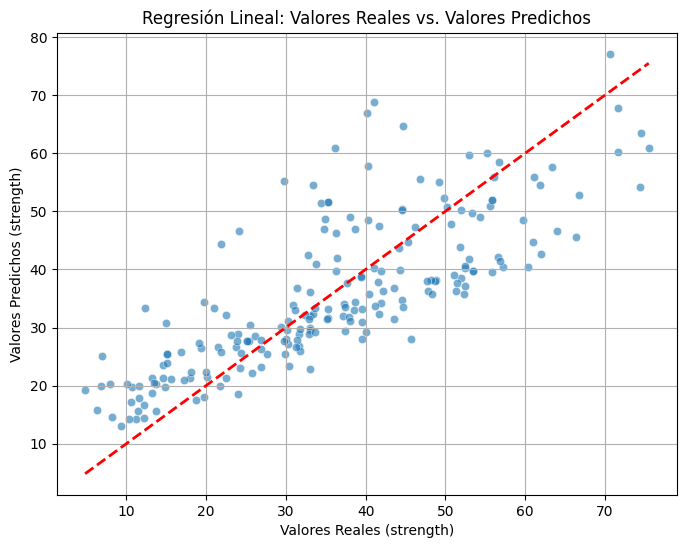

In [ ]:
# --- Modelo 1: Regresión Lineal ---
print("\n### Modelo: Regresión Lineal")
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
y_pred_linear = linear_model.predict(X_test_reg)

# Métricas Regresión Lineal
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)

print(f"MSE (Regresión Lineal): {mse_linear:.4f}")
print(f"R2 Score (Regresión Lineal): {r2_linear:.4f}")
print(f"MAE (Regresión Lineal): {mae_linear:.4f}")

# Gráfica de dispersión para Regresión Lineal
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_linear, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2) # Línea ideal
plt.title('Regresión Lineal: Valores Reales vs. Valores Predichos')
plt.xlabel('Valores Reales (strength)')
plt.ylabel('Valores Predichos (strength)')
plt.grid(True)
plt.show()

### Modelo: RandomForestRegressor

RandomForestRegressor puede dar buenos resultados por su capacidad para manejar relaciones no lineales, su robustez y menor propensión al sobreajuste. `n_estimators` se establece en 100.

Se evaluará con las mismas métricas que la Regresión Lineal: MSE, R2 Score y MAE, y se visualizará con una gráfica de dispersión.


### Modelo: RandomForestRegressor
MSE (RandomForestRegressor): 29.9422
R2 Score (RandomForestRegressor): 0.8838
MAE (RandomForestRegressor): 3.7385


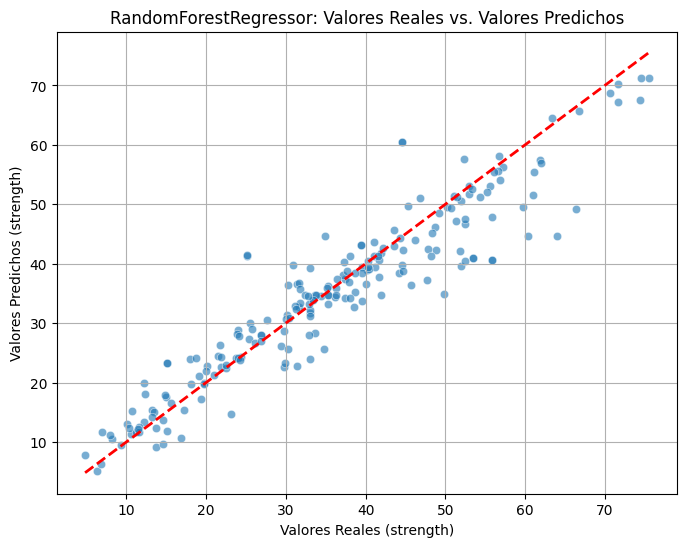

In [ ]:
# --- Modelo 2: RandomForestRegressor ---
print("\n### Modelo: RandomForestRegressor")
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

# Métricas RandomForestRegressor
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)

print(f"MSE (RandomForestRegressor): {mse_rf_reg:.4f}")
print(f"R2 Score (RandomForestRegressor): {r2_rf_reg:.4f}")
print(f"MAE (RandomForestRegressor): {mae_rf_reg:.4f}")

# Gráfica de dispersión para RandomForestRegressor
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_rf_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2) # Línea ideal
plt.title('RandomForestRegressor: Valores Reales vs. Valores Predichos')
plt.xlabel('Valores Reales (strength)')
plt.ylabel('Valores Predichos (strength)')
plt.grid(True)
plt.show()

### Modelo: GradientBoostingRegressor

Se añade GradientBoostingRegressor como otro modelo de ensamble potente. Es efectivo para capturar relaciones complejas y a menudo ofrece un gran rendimiento.

Al igual que los anteriores, se evaluará con MSE, R2 Score y MAE, y se visualizará con una gráfica de dispersión.


### Modelo: GradientBoostingRegressor
MSE (GradientBoostingRegressor): 30.1769
R2 Score (GradientBoostingRegressor): 0.8829
MAE (GradientBoostingRegressor): 4.1350


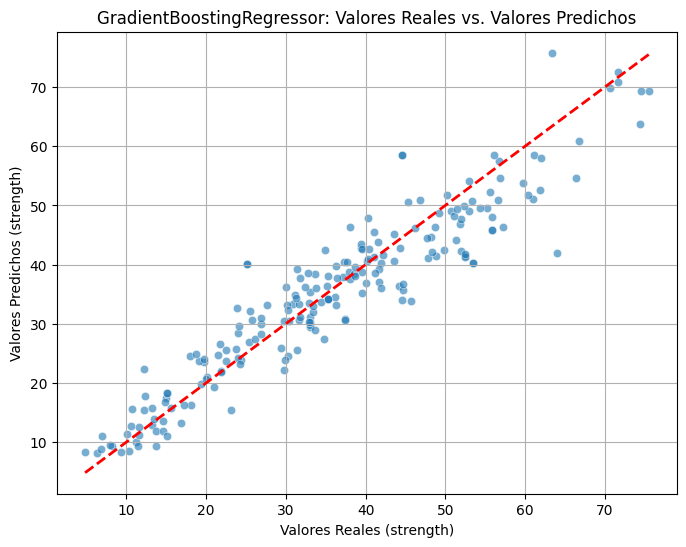

In [ ]:
# --- Modelo 3: GradientBoostingRegressor ---
print("\n### Modelo: GradientBoostingRegressor")
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(X_test_reg)

# Métricas GradientBoostingRegressor
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)

print(f"MSE (GradientBoostingRegressor): {mse_gbr:.4f}")
print(f"R2 Score (GradientBoostingRegressor): {r2_gbr:.4f}")
print(f"MAE (GradientBoostingRegressor): {mae_gbr:.4f}")

# Gráfica de dispersión para GradientBoostingRegressor
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_gbr, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('GradientBoostingRegressor: Valores Reales vs. Valores Predichos')
plt.xlabel('Valores Reales (strength)')
plt.ylabel('Valores Predichos (strength)')
plt.grid(True)
plt.show()

---

## Conclusiones Generales sobre los Modelos de Regresión

Tras entrenar y evaluar tres modelos de regresión, Regresión Lineal, RandomForestRegressor y GradientBoostingRegressor, para predecir la resistencia del hormigón, he sacado las siguientes conclusiones:

### Regresión Lineal
-   **MSE (Mean Squared Error):** 95.9709
-   **R2 Score (Coeficiente de determinación):** 0.6276
-   **MAE (Mean Absolute Error):** 7.7456
-   **Características:** la Regresión Lineal es un modelo simple y paramétrico que asume una relación lineal entre las variables de entrada y la variable objetivo. Es fácil de interpretar y eficiente.
-   **Análisis de Métricas:** el R2 Score de 0.6276 indica que este modelo explica aproximadamente el 62.76% de la varianza en la resistencia del hormigón, lo cual es un rendimiento moderado. El MSE y MAE son relativamente altos, sugiriendo que las predicciones tienen una desviación considerable de los valores reales.

### RandomForestRegressor
-   **MSE (Mean Squared Error):** 29.9422
-   **R2 Score (Coeficiente de determinación):** 0.8838
-   **MAE (Mean Absolute Error):** 3.7385
-   **Características:** RandomForestRegressor es un modelo de ensamble no paramétrico que construye múltiples árboles de decisión y combina sus predicciones. Es conocido por su robustez, capacidad para manejar relaciones no lineales y menor propensión al sobreajuste en comparación con un solo árbol de decisión. Requiere la configuración de parámetros como `n_estimators`.
-   **Análisis de Métricas:** este modelo muestra un rendimiento significativamente superior al de la Regresión Lineal. Un R2 Score de 0.8838 significa que explica casi el 88.38% de la varianza, lo que es una mejora sustancial. Los valores de MSE y MAE son mucho más bajos, indicando predicciones considerablemente más precisas y un menor error promedio.

### GradientBoostingRegressor
-   **MSE (Mean Squared Error):** 30.1769
-   **R2 Score (Coeficiente de determinación):** 0.8829
-   **MAE (Mean Absolute Error):** 4.1350
-   **Características:** GradientBoostingRegressor es otro modelo de ensamble que construye secuencialmente árboles de decisión, donde cada nuevo árbol corrige los errores del anterior. Es muy eficaz para problemas de regresión y puede capturar relaciones complejas en los datos.
-   **Análisis de Métricas:** este modelo también muestra un rendimiento muy bueno, similar al RandomForestRegressor y muy superior a la Regresión Lineal. Su R2 Score de 0.8829 es casi idéntico al de Random Forest. El MSE y MAE también son bajos, indicando predicciones precisas.

### Comparación y Conclusión

Los modelos **RandomForestRegressor** y **GradientBoostingRegressor** han demostrado ser claramente superiores a la Regresión Lineal para la predicción de la resistencia del hormigón. Ambos modelos de ensamble capturan eficazmente las relaciones no lineales y complejas presentes en los datos, dando lugar a métricas de rendimiento (R2, MSE, MAE) significativamente mejores.

Entre RandomForestRegressor y GradientBoostingRegressor, los resultados son muy parecidos. RandomForestRegressor supera ligeramente a GradientBoostingRegressor en R2 Score y MAE, aunque la diferencia es mínima. Así, ambos modelos son excelentes candidatos para este problema, y la elección entre ellos podría depender de otros factores como el tiempo de entrenamiento para conjuntos de datos mucho más grandes.

La **Regresión Lineal**, al asumir una relación lineal, no es capaz de capturar la complejidad existente entre los ingredientes del hormigón y su resistencia, que probablemente es no lineal. Los modelos basados en árboles, como Random Forest y Gradient Boosting, son mucho más adecuados para este tipo de problema.